<a href="https://colab.research.google.com/github/Akhilesh1118/Telco-Customer-Churn-Analysis/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Analysis

## Problem Statement

Customer churn is one of the biggest challenges faced by telecom companies. Losing existing customers increases acquisition costs and reduces long-term revenue.

The objective of this project is to analyze customer behavior, identify factors contributing to churn, and provide actionable recommendations to improve customer retention.

## Project Goals

- Understand customer demographics
- Analyze churn patterns
- Identify key churn drivers
- Generate business recommendations

## Dataset Overview

The dataset contains customer demographic information, subscribed services, billing details, contract information, and churn status.

### Important Features

- Gender
- SeniorCitizen
- Tenure
- Contract
- PaymentMethod
- MonthlyCharges
- TotalCharges
- Churn (Target Variable)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv("Customer Churn.csv")

# Display the first few rows to understand the structure
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info() # Information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Cleaning: Handling `TotalCharges`
Some customers have blank values in `TotalCharges` because they are new customers with zero tenure.
These blanks are replaced with `0` and converted to numeric format.

In [ ]:
# Convert TotalCharges to numeric and handle blank values safely
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].dtype


dtype('float64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum().sum() # Give the sum of null values present in dataset

np.int64(0)

In [ ]:
# Dataset summary

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

summary

Number of Rows: 7043
Number of Columns: 21


,Data Type,Missing Values,Unique Values
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


In [ ]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [ ]:
# Verify that customer IDs are unique
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
# Convert 0/1 values to No/Yes for readability
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

Converted `0` and `1` in `SeniorCitizen` to `No` and `Yes` for better readability.

## Customer Churn Distribution (Bar Chart)

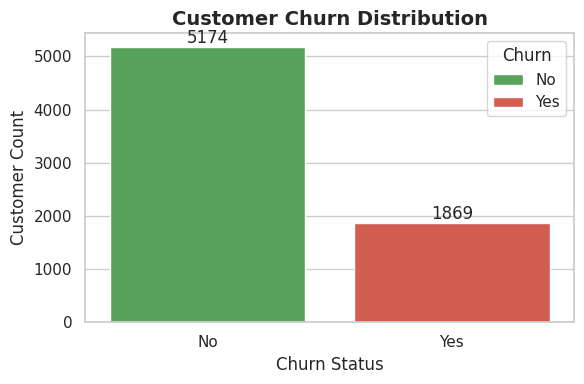

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette=["#4CAF50", "#E74C3C"],
    legend=True
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()

## Customer Churn Distribution (Pie Chart)

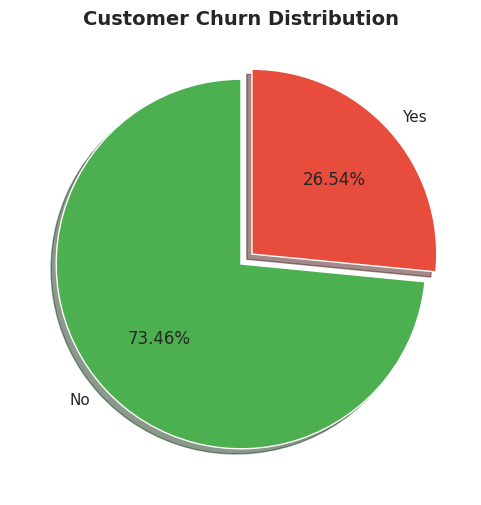

In [ ]:
colors = ["#4CAF50", "#E74C3C"]  # Green = Stayed, Red = Churned

plt.figure(figsize=(6,6))

plt.pie(
    gb["Churn"],
    labels=gb.index,
    autopct="%1.2f%%",
    colors=colors,
    explode=[0, 0.08],   # Highlight churn section
    shadow=True,
    startangle=90
)

plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.show()

The pie chart shows that around 26.54% of customers have churned.

## Gender vs Churn Analysis

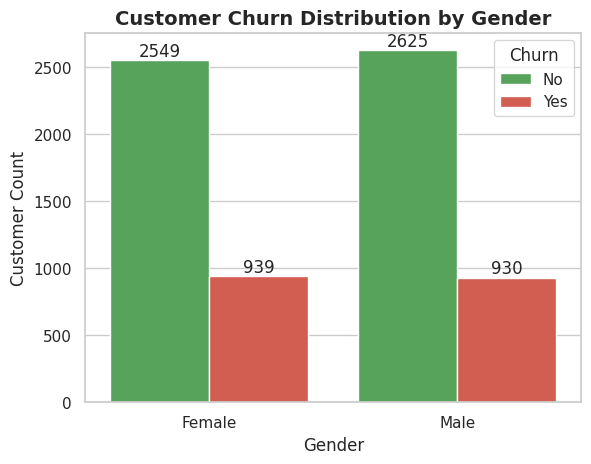

In [ ]:
ax = sns.countplot(
    x="gender",
    hue="Churn",
    data=df,
    palette={
        "No": "#4CAF50",
        "Yes": "#E74C3C"
    }
)

for container in ax.containers:
    ax.bar_label(container)
plt.title("Customer Churn Distribution by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

## Senior Citizen vs Churn Analysis

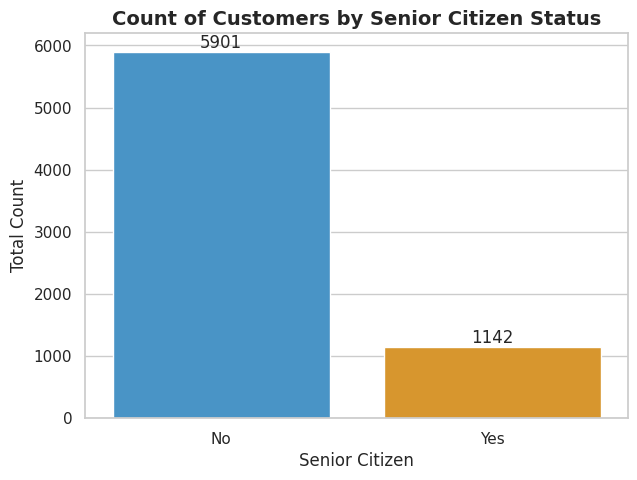

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x='SeniorCitizen',
    data=df,
    hue='SeniorCitizen',
    palette={
        "No": "#3498DB",   # Blue
        "Yes": "#F39C12"   # Orange
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Count of Customers by Senior Citizen Status', fontsize=14, fontweight="bold")
plt.xlabel('Senior Citizen')
plt.ylabel('Total Count')

plt.show()

## Churn Percentage by Senior Citizen Category

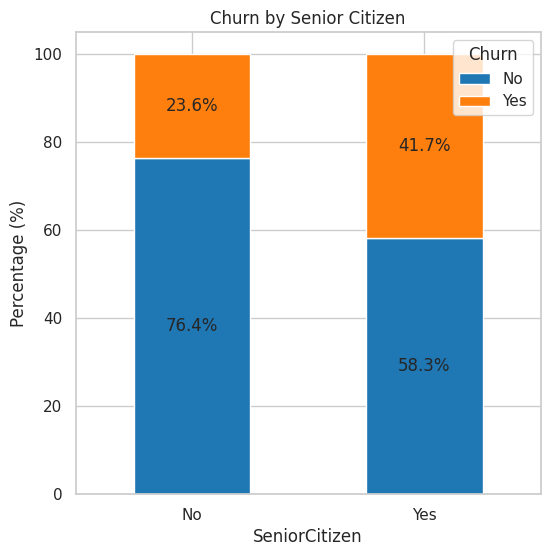

In [ ]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(6, 6))  # Adjust figsize for better visualization

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Customize colors if desired

# Add percentage Labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', loc='upper right')  # Customize Legend Location

plt.show()

A higher percentage of senior citizen customers have churned compared to non-senior customers.

## Tenure Distribution by Churn Status

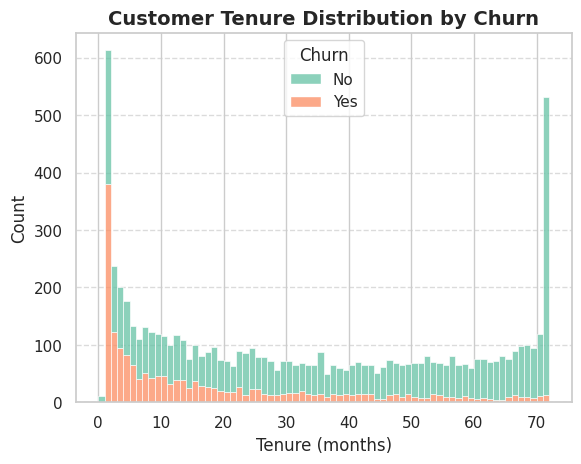

In [ ]:
sns.histplot(x="tenure",hue="Churn",data=df, bins= 72 ,multiple="stack")
plt.title("Customer Tenure Distribution by Churn", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Customers with longer tenure are more likely to stay, while customers with shorter tenure are more likely to churn.

## Contract Type vs Churn Analysis

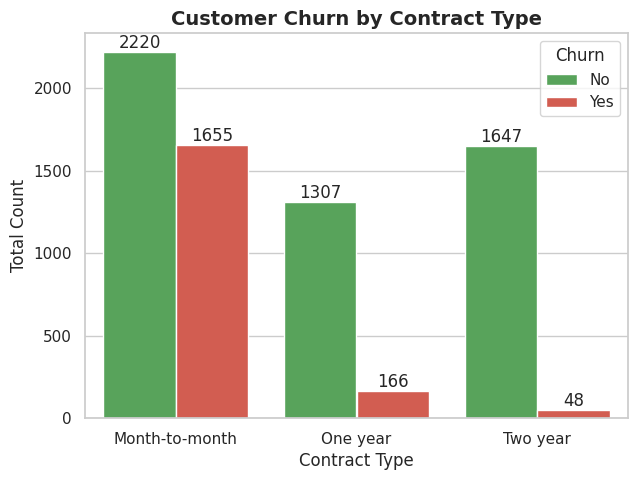

In [ ]:
plt.figure(figsize=(7, 5))
# Plotting Contract with bar labels added back
ax = sns.countplot(
    x='Contract',
    data=df,
    hue='Churn',
    palette={
        "No": "#4CAF50",
        "Yes": "#E74C3C"
    }
)
# Adding bar labels on top
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel('Contract Type')
plt.ylabel('Total Count')
plt.show()

Customers with month-to-month contracts are more likely to churn than customers with one-year or two-year contracts.

## Service Features Impact on Churn

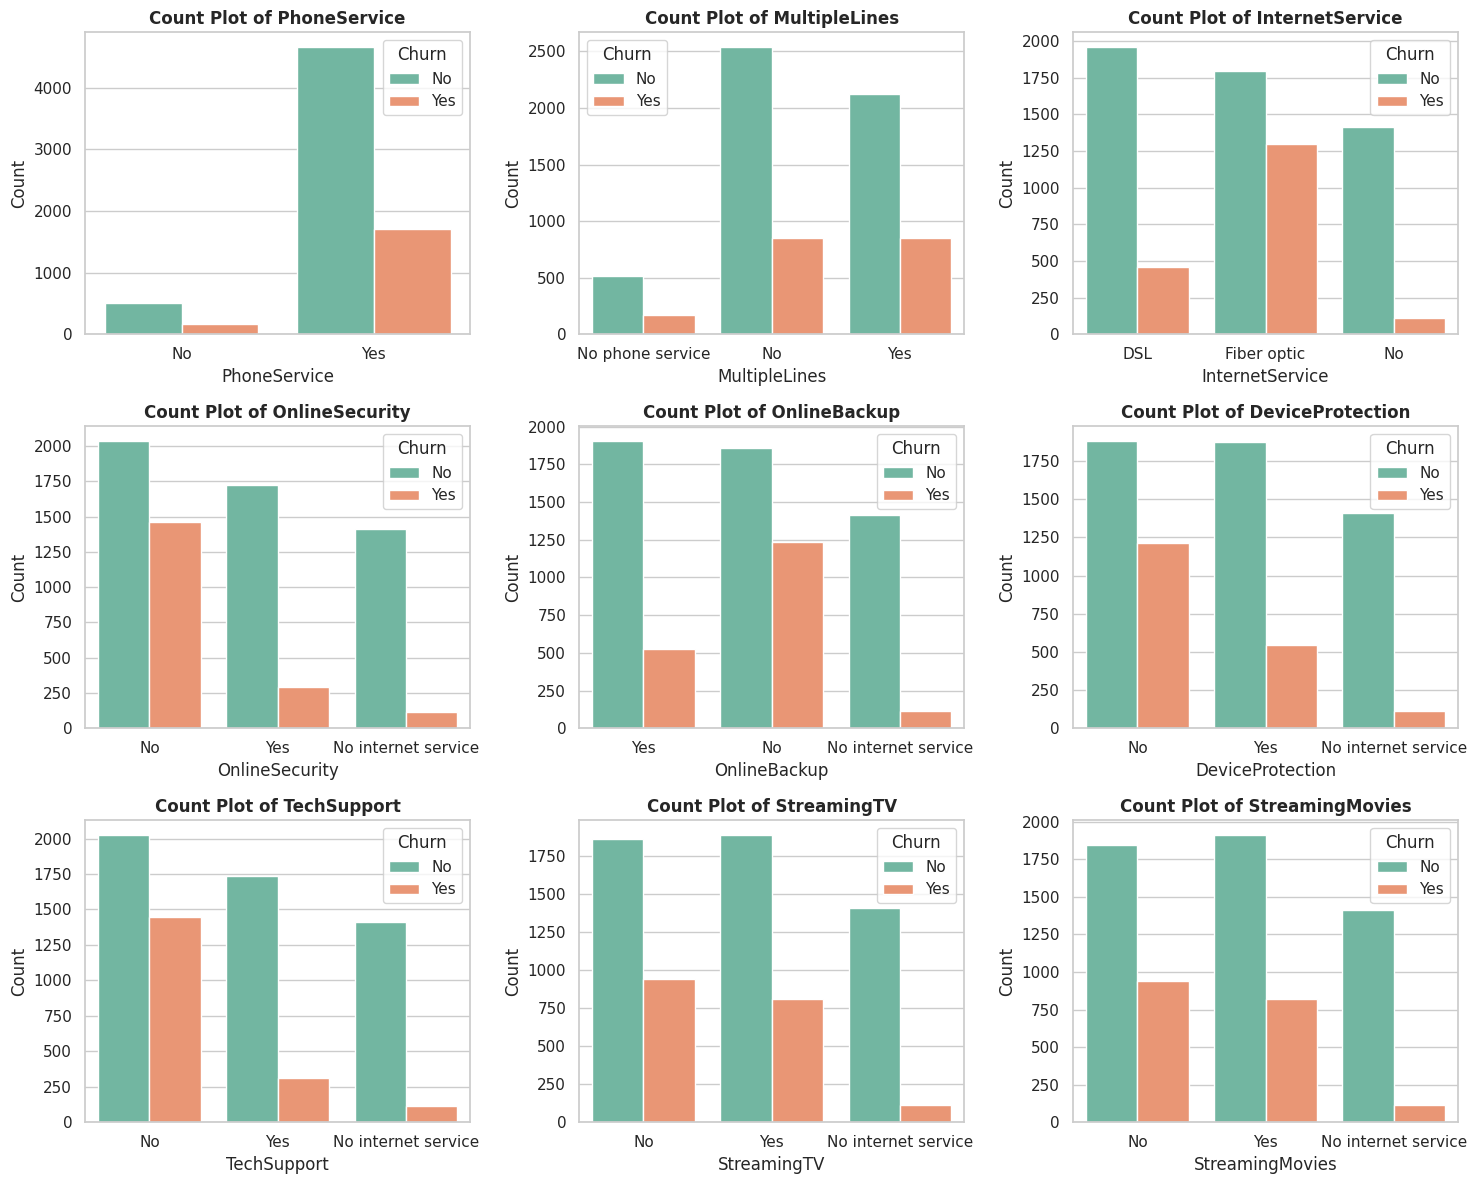

In [ ]:
# List of columns for which we want to create count plots
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Number of columns for the subplot grid (you can change this)
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))  # Adjust figsize as needed

# Flatten the axes array for easy iteration (handles both 1D and 2D arrays)
axes = axes.flatten()

# Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue="Churn")
    axes[i].set_title(f'Count Plot of {col}', fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots
for i in range(len(columns), len(axes)):
    fig.delaxes(axes[i])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

### Service Analysis Insights

Customers who retain services such as Online Security, Tech Support, and Device Protection tend to exhibit lower churn rates.

Customers without these value-added services show a higher tendency to leave the company.

## Payment Method vs Churn Analysis

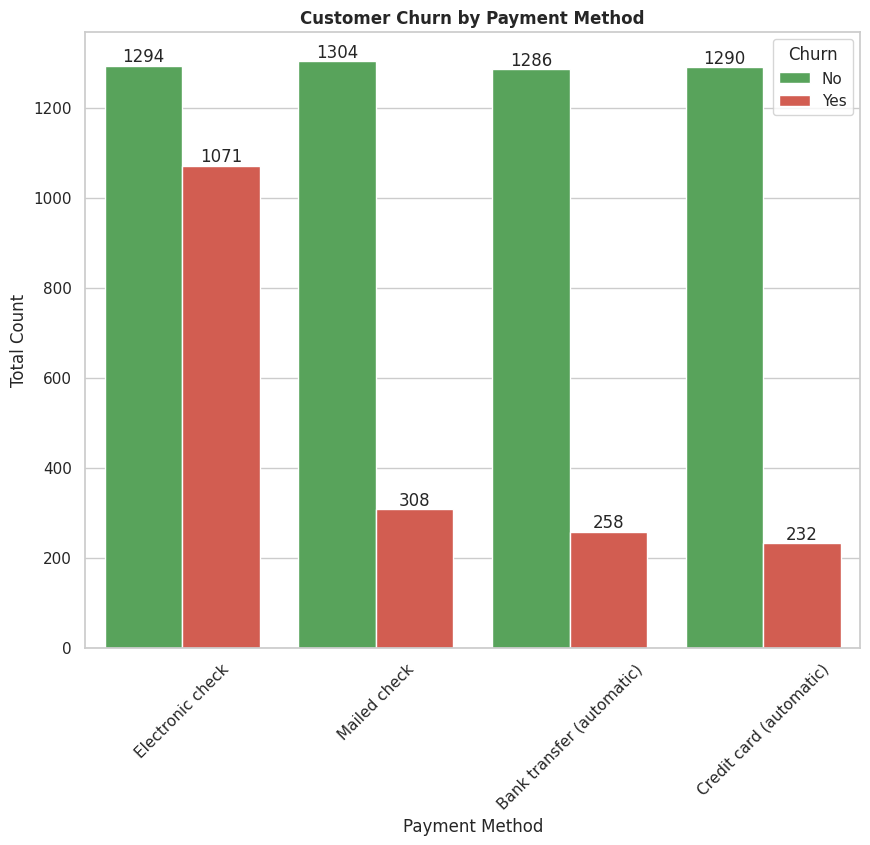

In [ ]:
plt.figure(figsize=(10, 8))
# Plotting PaymentMethod with bar labels added back
ax = sns.countplot(
    x='PaymentMethod',
    data=df,
    hue='Churn',
    palette={
        "No": "#4CAF50",
        "Yes": "#E74C3C"
    }
)

# Adding bar labels on top
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Payment Method", fontsize=12, fontweight="bold")
plt.xlabel('Payment Method')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.show()

### Insight

Customers using Electronic Check exhibit the highest churn rate among all payment methods, suggesting potential dissatisfaction or behavioral differences within this customer segment.

## Correlation Analysis Heatmap

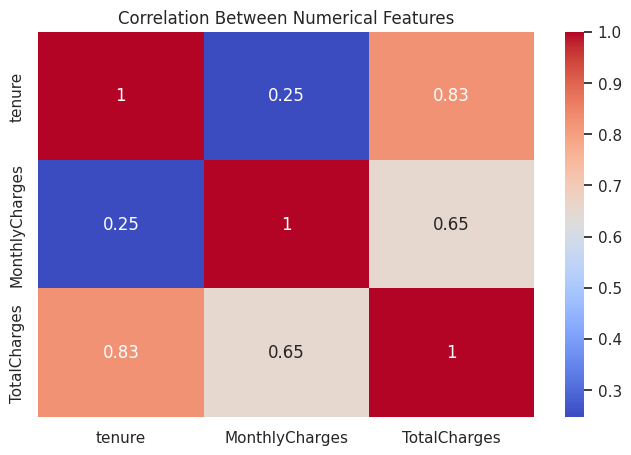

In [ ]:
# Correlation between numerical features

plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")
plt.show()

### Insight

Month-to-month customers have the highest churn percentage, while customers with long-term contracts are significantly more likely to stay.

# Key Findings

1. Approximately 26.5% of customers have churned.
2. Month-to-month contracts show the highest churn rate.
3. Customers with shorter tenure are more likely to churn.
4. Senior citizens have a relatively higher churn percentage.
5. Electronic Check users demonstrate the highest churn tendency.
6. Customers using Online Security and Tech Support services tend to stay longer.

# Business Recommendations

1. Encourage customers to switch from month-to-month contracts to yearly plans.
2. Create retention campaigns for customers during their first year.
3. Investigate why Electronic Check customers churn more frequently.
4. Offer loyalty rewards to long-term customers.
5. Provide targeted support for senior citizen customers.

# Final Conclusion

The analysis identified Contract Type, Tenure, Senior Citizen status, and Payment Method as major factors influencing customer churn.

Customers with month-to-month contracts, low tenure, and Electronic Check payment methods showed the highest likelihood of churn.

These insights can help telecom companies design targeted retention strategies and improve customer loyalty.